# Exploratory Data Analysis

### Importing libraries and dataset

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import math
from functions import corr_heatmap, outlier_detection, check_duplicates, categorical_distributions

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
df = pd.read_csv("wfh_burnout_dataset.csv")
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            2000 non-null   int64  
 1   day_type           2000 non-null   object 
 2   work_hours         2000 non-null   float64
 3   screen_time_hours  2000 non-null   float64
 4   meetings_count     2000 non-null   int64  
 5   breaks_taken       2000 non-null   int64  
 6   after_hours_work   2000 non-null   int64  
 7   app_switches       2000 non-null   int64  
 8   sleep_hours        2000 non-null   float64
 9   task_completion    2000 non-null   float64
 10  isolation_index    2000 non-null   int64  
 11  fatigue_score      2000 non-null   float64
 12  burnout_score      2000 non-null   float64
 13  burnout_risk       2000 non-null   object 
dtypes: float64(6), int64(6), object(2)
memory usage: 218.9+ KB


Isolating numerical and categorical columns for methods used later on in the notebook

In [5]:
num_cols = df.select_dtypes(include=[np.number]).drop('user_id', axis=1).columns.tolist()
cat_cols = df.select_dtypes(include=[object])


### Duplicates check

Checking for duplicate rows

In [15]:
check_duplicates(df)

Duplicate rows: 0


### Missing Values

Checking for missing values in the dataset

In [4]:
nan_counts = df.isnull().sum()
print(nan_counts)

user_id              0
day_type             0
work_hours           0
screen_time_hours    0
meetings_count       0
breaks_taken         0
after_hours_work     0
app_switches         0
sleep_hours          0
task_completion      0
isolation_index      0
fatigue_score        0
burnout_score        0
burnout_risk         0
dtype: int64


### Numerical variables distribution

Checking for the numerical variables distribution in boxplots to identify potential outliers

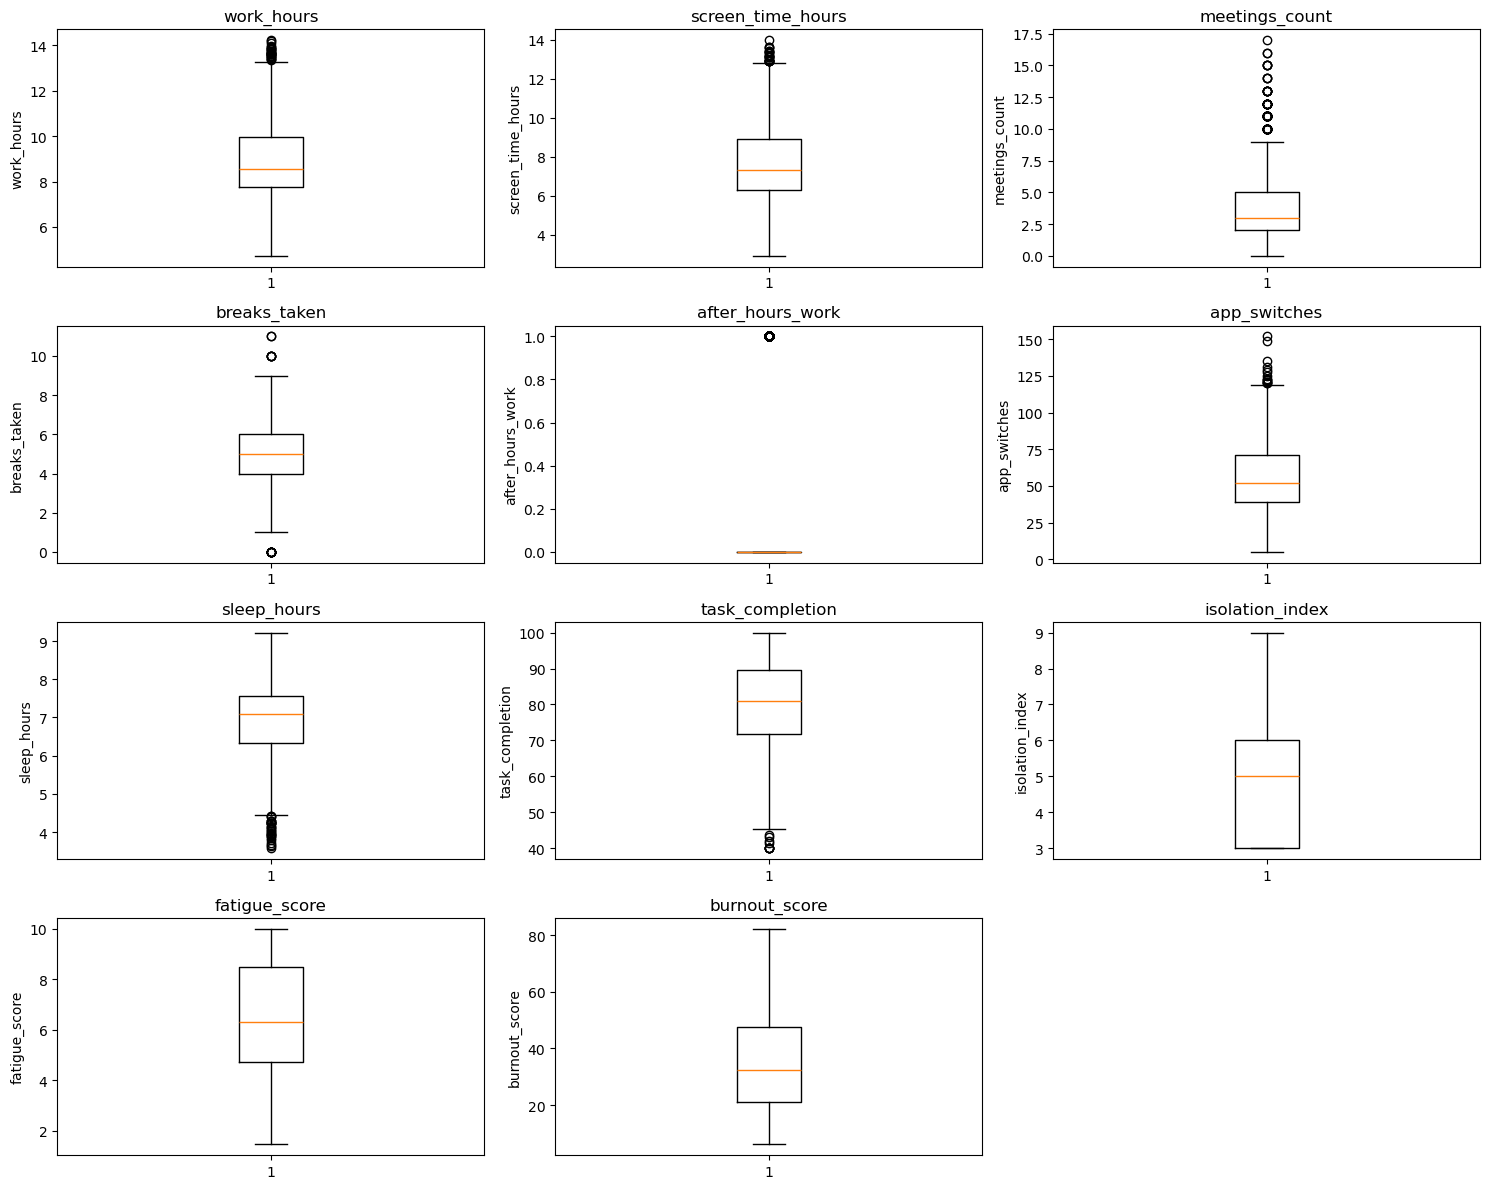

In [9]:
outlier_detection(df[num_cols])

As the column 'after_hours_work' only has 2 values, we'll create a bar chart to check for the distribution between 0 and 1 to verify if the information from said column isn't mostly constant (and later on encode this column if useful).

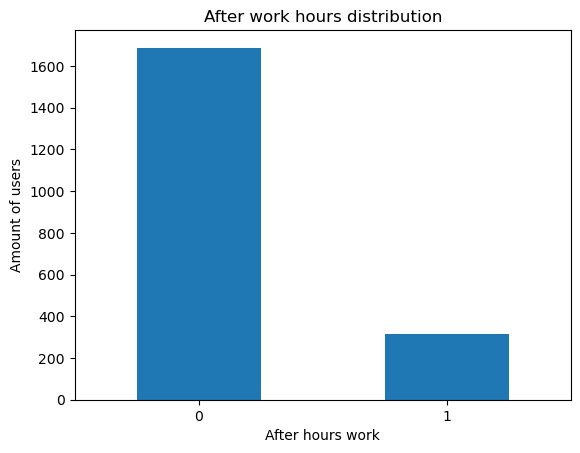

In [20]:
df['after_hours_work'].value_counts().sort_index().plot(kind='bar')
plt.title('After work hours distribution')
plt.xlabel('After hours work')
plt.ylabel('Amount of users')
plt.xticks(rotation=0)
plt.show()

### Categorical variables distributions

Using barcharts to check the categorical columns distributions

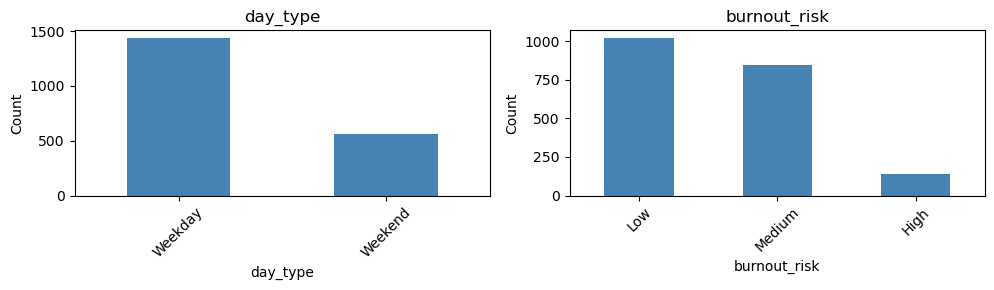

In [23]:
categorical_distributions(df)

### Correlations between variables

Creating a correlation heatmap to check for variables that are highly correlated


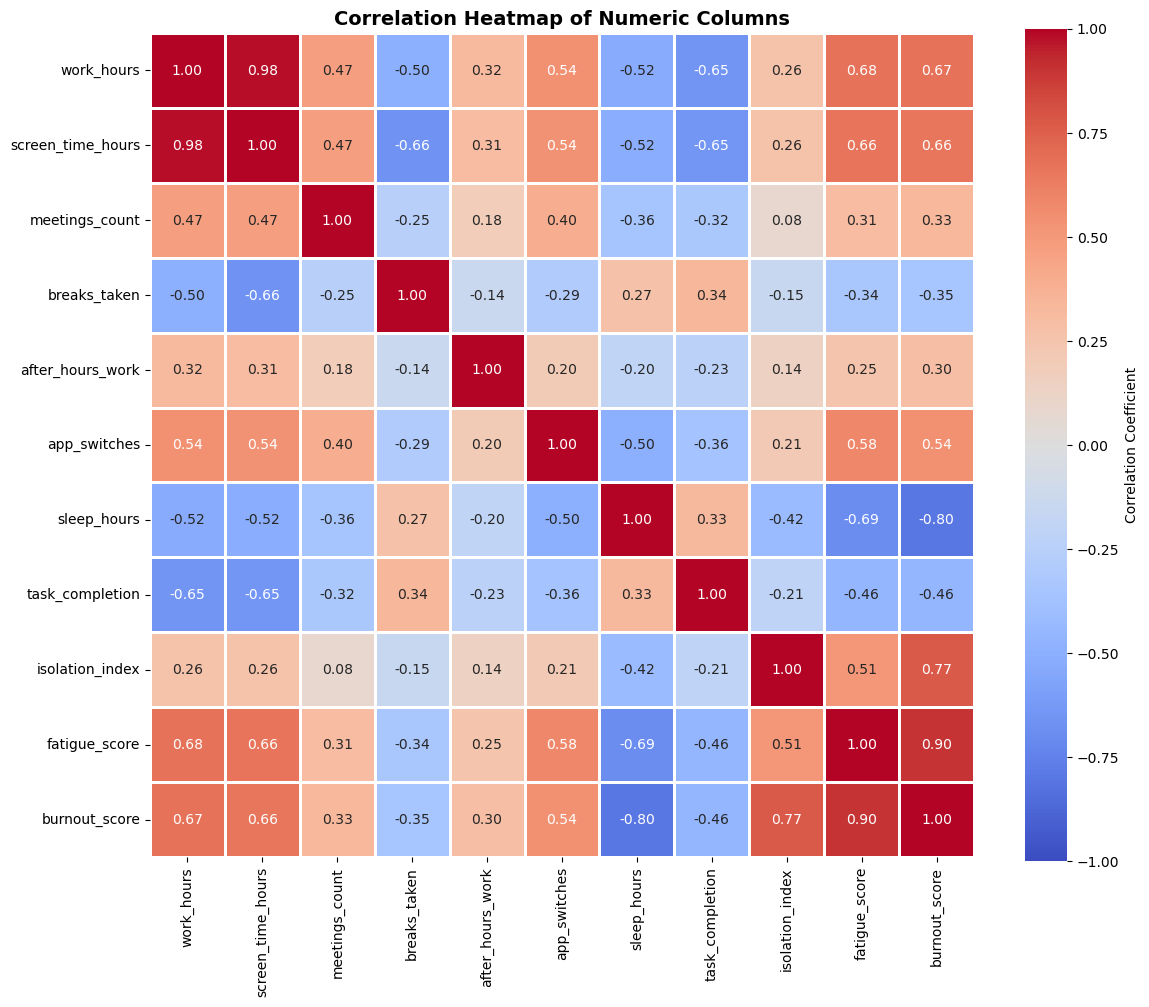

In [49]:
corr_heatmap(df, num_cols)